# Bird Data and Air Pollution Correlation Analysis
This notebook investigates the relationship between bird occurrence counts (`individualCount`) and various air pollution metrics from the integrated dataset. All other environmental and climate variables have been excluded to focus solely on this interaction.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visualizations
sns.set_theme(style="whitegrid")
%matplotlib inline

## Data Loading and Formatting
Load `file6.csv` and keep only these columns: `verbatimScientificName`, `stateProvince`, `individualCount`, `decimalLatitude`, `decimalLongitude`, `eventDate`, and the six air-pollution variables.

In [2]:
from pathlib import Path

# Locate dataset robustly from notebook location
candidate_paths = [Path('file6.csv'), Path('../file6.csv'), Path('../../file6.csv')]
data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError('file6.csv not found in current or parent directories.')

# Read dataset
df = pd.read_csv(data_path)

# Required columns (only)
pollution_cols = [
    'Carbon_Mass',
    'Dust_Mass',
    'SO2_Mass',
    'Sulfate_Mass',
    'Sea_Salt_Mass',
    'Total_Aerosol_Extinction'
    ]

core_cols = [
    'verbatimScientificName',
    'stateProvince',
    'individualCount',
    'decimalLatitude',
    'decimalLongitude',
    'eventDate'
    ]

required_cols = core_cols + pollution_cols
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in file6.csv: {missing_cols}")

analysis_df = df[required_cols].copy()

# Clean and standardize
analysis_df['eventDate'] = pd.to_datetime(analysis_df['eventDate'], errors='coerce')
analysis_df['individualCount'] = pd.to_numeric(analysis_df['individualCount'], errors='coerce')
analysis_df = analysis_df.dropna(subset=['eventDate', 'individualCount'] + pollution_cols + ['verbatimScientificName'])

display(analysis_df.head())
print(f"Using file: {data_path}")
print(f"Rows after cleaning: {len(analysis_df):,}")
print(f"Unique scientific names: {analysis_df['verbatimScientificName'].nunique():,}")

,verbatimScientificName,stateProvince,individualCount,decimalLatitude,decimalLongitude,eventDate,Carbon_Mass,Dust_Mass,SO2_Mass,Sulfate_Mass,Sea_Salt_Mass,Total_Aerosol_Extinction
0,Anarhynchus alexandrinus,Mannar,8.0,9.058512,79.85502,2021-01-06,5.794512e-10,1.548033e-09,1.643020e-10,3.372161e-09,3.725563e-08,0.175115
1,Hirundo rustica,Colombo,10.0,6.866285,79.93144,2024-12-23,9.678071e-10,2.117789e-09,4.725881e-09,4.424376e-09,3.249729e-08,0.198127
2,Corvus macrorhynchos,Matara,2.0,5.983496,80.52548,2024-10-12,2.578500e-10,3.088314e-09,1.444164e-09,7.456183e-10,5.362027e-08,0.131458
3,Dicrurus caerulescens,Matale,1.0,7.969125,80.75477,2021-11-20,4.901116e-10,6.928122e-09,1.376567e-09,1.612494e-09,3.017664e-08,0.123156
4,Threskiornis melanocephalus,Jaffna,30.0,9.637712,79.95190,2019-03-25,4.829281e-10,2.295270e-08,3.812554e-10,2.737918e-09,3.224930e-08,0.220155


Using file: ../file6.csv
Rows after cleaning: 1,552,048
Unique scientific names: 429


## Correlation Heatmap (Air Pollution Only)
This heatmap shows linear correlations between `individualCount` and only the six air-pollution features.

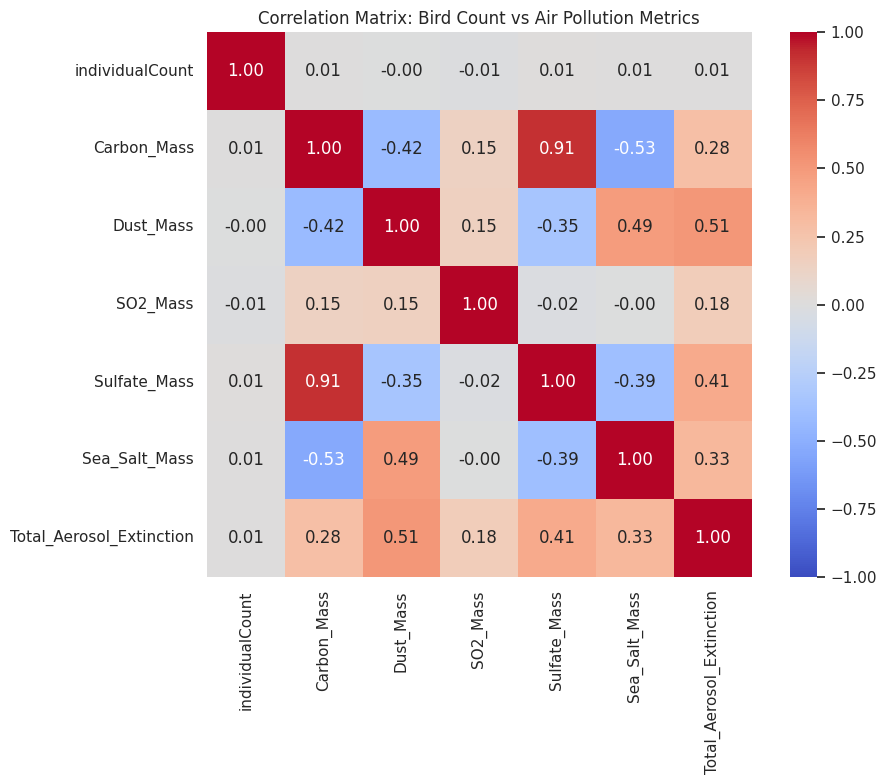

In [6]:
corr_cols = ['individualCount'] + pollution_cols
corr_matrix = analysis_df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, square=True)
plt.title('Correlation Matrix: Bird Count vs Air Pollution Metrics')
plt.tight_layout()
plt.show()

## Scatter Plots (Bird Count vs Each Pollutant)
These plots visualize the direct relationship between `individualCount` and each air-pollution feature.

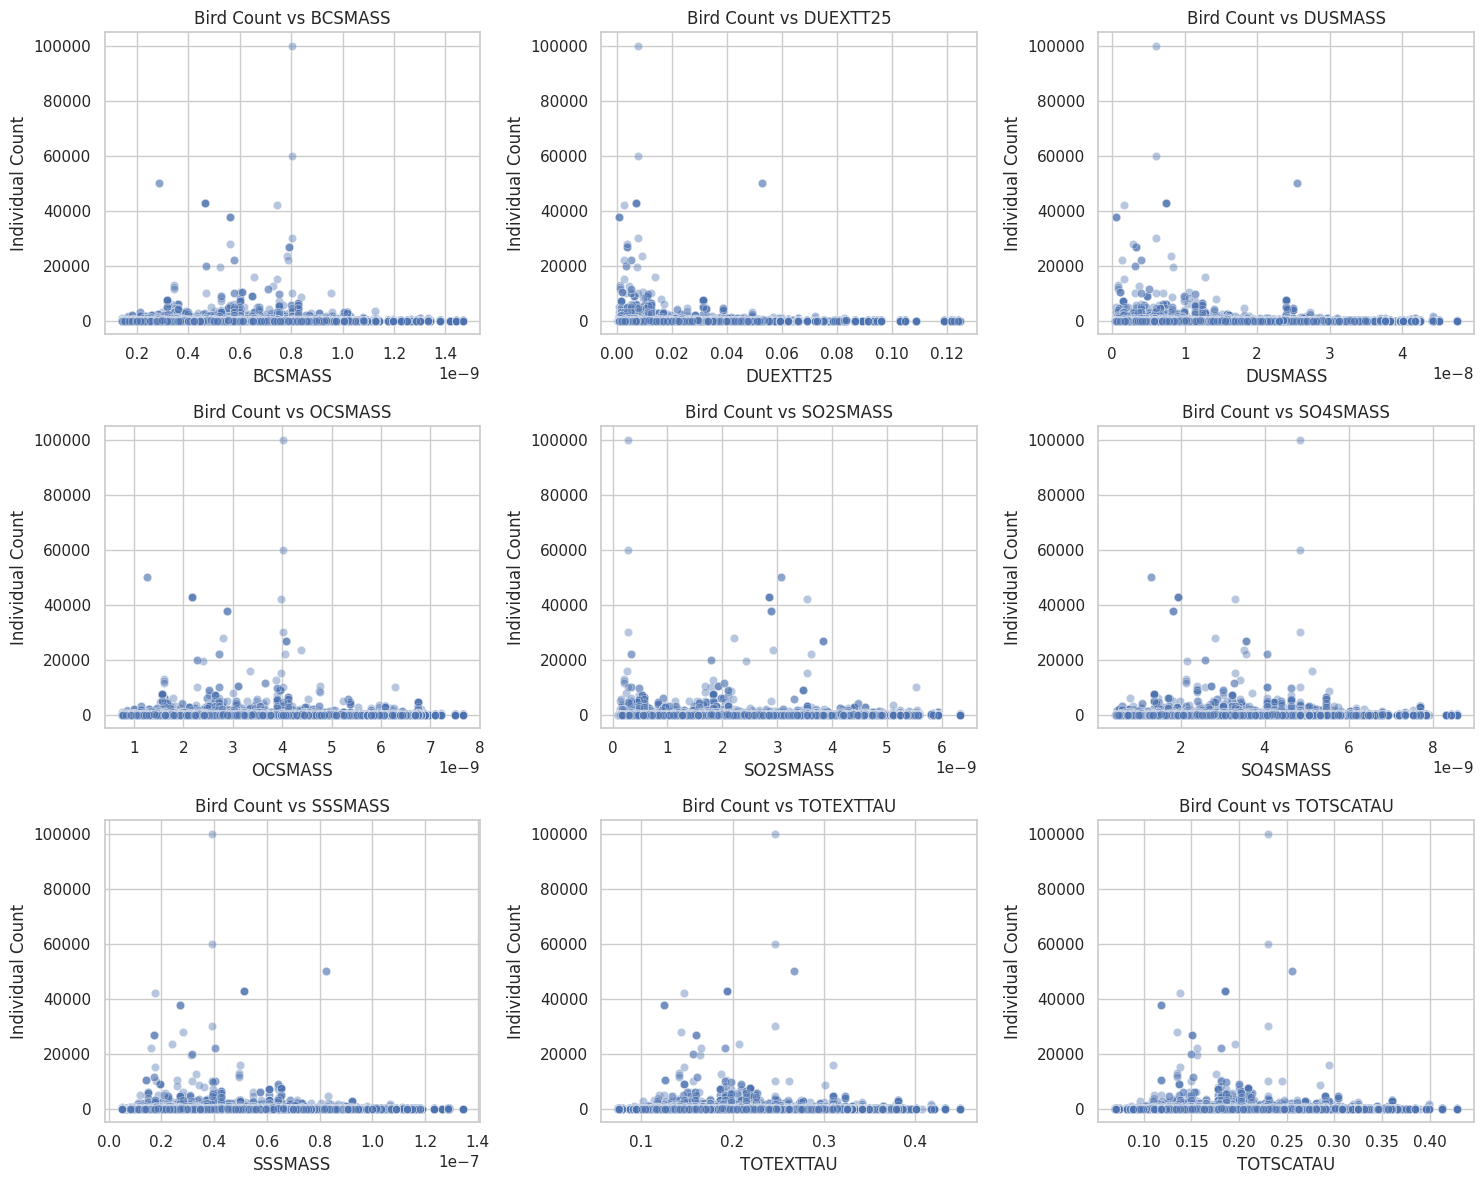

In [ ]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(pollution_cols, 1):
    plt.subplot(2, 3, i)
    sns.scatterplot(data=analysis_df, x=col, y='individualCount', alpha=0.35, s=20)
    plt.title(f'Bird Count vs {col}')
    plt.xlabel(col)
    plt.ylabel('Individual Count')

plt.tight_layout()
plt.show()

## Time Series (Bird Count vs Total Aerosol Extinction)
Aggregate by date to compare total bird observations against daily mean `Total_Aerosol_Extinction`.

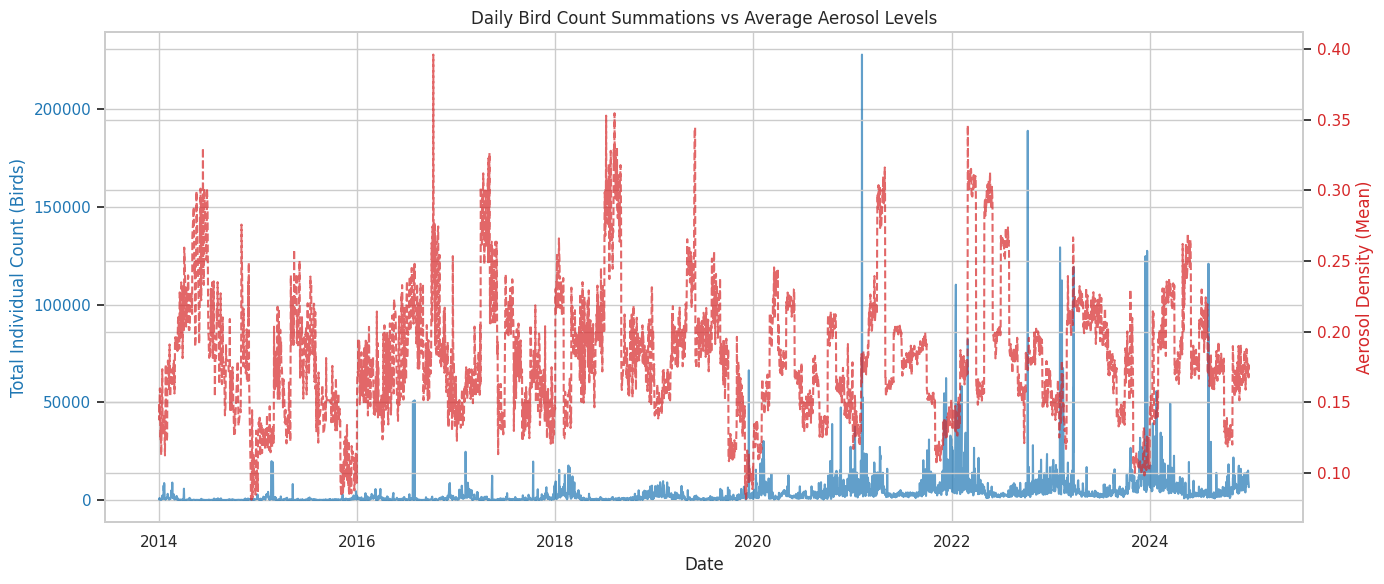

In [ ]:
daily_agg = analysis_df.groupby('eventDate', as_index=False).agg({
    'individualCount': 'sum',
    'Total_Aerosol_Extinction': 'mean'
})

fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(daily_agg['eventDate'], daily_agg['individualCount'], color='tab:blue', alpha=0.7)
ax1.set_xlabel('Date')
ax1.set_ylabel('Total Individual Count', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(
    daily_agg['eventDate'],
    daily_agg['Total_Aerosol_Extinction'],
    color='tab:red', linestyle='--', alpha=0.7
    )
ax2.set_ylabel('Mean Total Aerosol Extinction', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Daily Bird Count vs Mean Total Aerosol Extinction')
fig.tight_layout()
plt.show()

## Geospatial Distribution
Map observation points, coloring by `Total_Aerosol_Extinction` and sizing by `individualCount`.

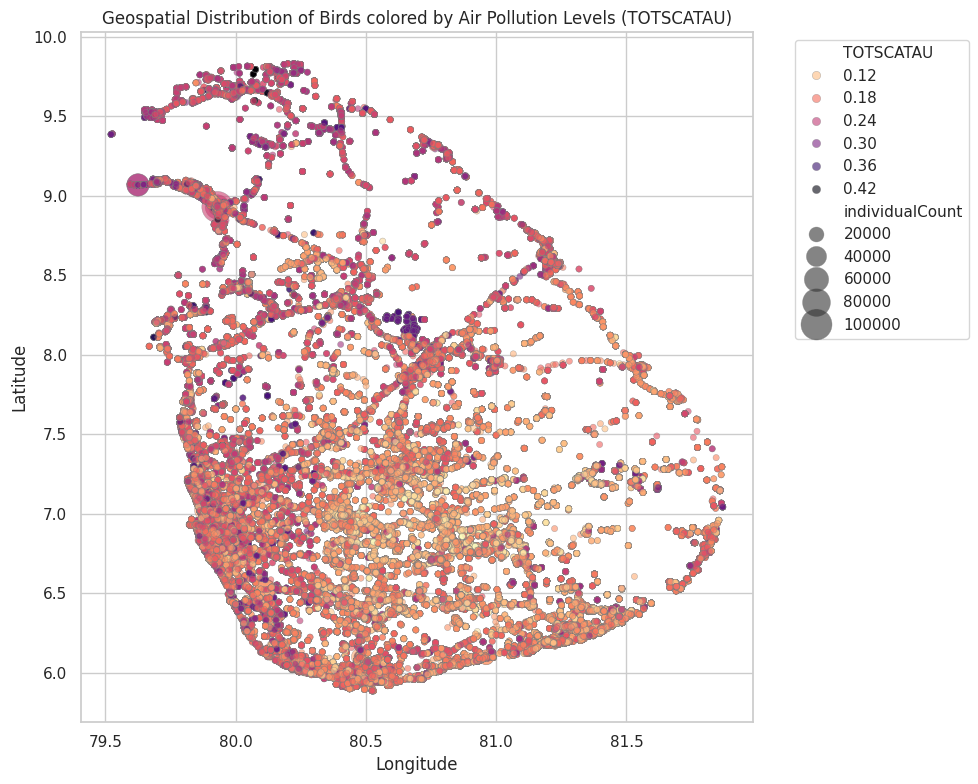

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=analysis_df,
    x='decimalLongitude',
    y='decimalLatitude',
    hue='Total_Aerosol_Extinction',
    size='individualCount',
    sizes=(20, 400),
    palette='magma_r',
    alpha=0.6,
    edgecolor='gray'
    )

plt.title('Bird Observations Colored by Total Aerosol Extinction')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

## Species-Level Correlations (verbatimScientificName)
Estimate per-species correlations between `individualCount` and each air-pollution feature. Species with low sample size are filtered out for stability.

,Carbon_Mass,Dust_Mass,SO2_Mass,Sulfate_Mass,Sea_Salt_Mass,Total_Aerosol_Extinction,verbatimScientificName,n_records
0,0.014247,-0.030314,-0.083725,0.010484,-0.038641,-0.036476,Pycnonotus cafer,43378
1,0.007884,-0.039305,-0.109878,0.009126,-0.017431,-0.039773,Spilopelia chinensis,41311
2,0.012072,-0.028928,-0.040561,0.011693,-0.007428,-0.020779,Acridotheres tristis,36738
3,0.017369,-0.004610,0.057897,0.012698,0.021292,0.013547,Psittacula krameri,32501
4,-0.013275,-0.009841,-0.066426,-0.004135,0.017290,-0.016347,Halcyon smyrnensis,32413
5,0.026874,0.004466,0.008566,0.016820,-0.013754,0.010287,Argya affinis,31034
6,-0.006952,0.027952,-0.030176,0.004693,-0.003487,0.034593,Psilopogon zeylanicus,29419
7,-0.019141,0.035933,0.035976,-0.018092,0.006377,0.001210,Orthotomus sutorius,29269
8,0.027719,-0.022255,0.013232,0.017225,-0.030397,-0.011534,Corvus splendens,29264
9,-0.012235,0.017793,-0.025726,-0.006615,0.007959,0.015669,Leptocoma zeylonica,26849


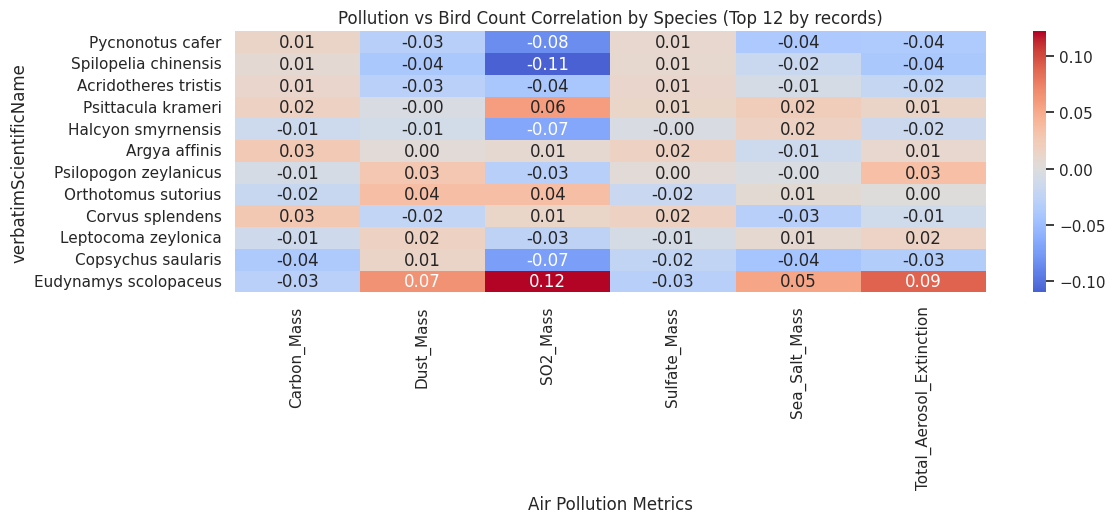

In [7]:
min_records = 30
species_counts = analysis_df['verbatimScientificName'].value_counts()
valid_species = species_counts[species_counts >= min_records].index

species_corr_rows = []
for species in valid_species:
    subset = analysis_df[analysis_df['verbatimScientificName'] == species]
    corr_series = subset[pollution_cols + ['individualCount']].corr(numeric_only=True)['individualCount']
    row = corr_series.drop(labels='individualCount').to_dict()
    row['verbatimScientificName'] = species
    row['n_records'] = len(subset)
    species_corr_rows.append(row)

species_corr_df = pd.DataFrame(species_corr_rows).sort_values('n_records', ascending=False).reset_index(drop=True)
display(species_corr_df.head(15))

top_n = min(12, len(species_corr_df))
if top_n > 0:
    plt.figure(figsize=(12, max(5, top_n * 0.45)))
    heatmap_df = species_corr_df.head(top_n).set_index('verbatimScientificName')[pollution_cols]
    sns.heatmap(heatmap_df, annot=True, cmap='coolwarm', center=0, fmt='.2f')
    plt.title(f'Pollution vs Bird Count Correlation by Species (Top {top_n} by records)')
    plt.xlabel('Air Pollution Metrics')
    plt.ylabel('verbatimScientificName')
    plt.tight_layout()
    plt.show()
else:
    print('No species met the minimum record threshold.')

## Full Report: Key Rankings and Interesting Facts
This section summarizes pollution-only findings globally and by species (`verbatimScientificName`).

In [8]:
# 1) Overall pollution ranking by absolute correlation with bird counts
overall_corr = (
    analysis_df[pollution_cols]
    .corrwith(analysis_df['individualCount'])
    .rename('corr_with_individualCount')
    .sort_values(key=lambda s: s.abs(), ascending=False)
    )
display(overall_corr.to_frame())

# 2) Species-metric pairs with strongest positive and negative correlations
if 'species_corr_df' in locals() and not species_corr_df.empty:
    long_corr = species_corr_df.melt(
        id_vars=['verbatimScientificName', 'n_records'],
        value_vars=pollution_cols,
        var_name='pollution_metric',
        value_name='corr'
    ).dropna()

    strongest_positive = long_corr.sort_values('corr', ascending=False).head(10)
    strongest_negative = long_corr.sort_values('corr', ascending=True).head(10)

    print('Top 10 strongest positive species-pollution correlations')
    display(strongest_positive[['verbatimScientificName', 'pollution_metric', 'corr', 'n_records']])

    print('Top 10 strongest negative species-pollution correlations')
    display(strongest_negative[['verbatimScientificName', 'pollution_metric', 'corr', 'n_records']])

    # 3) Most pollution-responsive species (average absolute correlation across pollutants)
    species_response = (
        species_corr_df.set_index('verbatimScientificName')[pollution_cols]
        .abs()
        .mean(axis=1)
        .rename('mean_abs_corr')
        .sort_values(ascending=False)
        .head(10)
        )

    print('Top 10 most pollution-responsive species (mean absolute correlation)')
    display(species_response.to_frame())

else:
    print('Species-level correlation table is empty. Lower min_records if needed.')

,corr_with_individualCount
Sulfate_Mass,0.012039
SO2_Mass,-0.009733
Carbon_Mass,0.006839
Sea_Salt_Mass,0.006280
Total_Aerosol_Extinction,0.006275
Dust_Mass,-0.001667


Top 10 strongest positive species-pollution correlations


,verbatimScientificName,pollution_metric,corr,n_records
668,Merops persicus,Dust_Mass,0.736460,63
1368,Merops persicus,Sulfate_Mass,0.736460,63
2068,Merops persicus,Total_Aerosol_Extinction,0.736460,63
695,Anous stolidus,Dust_Mass,0.579279,32
1023,Stercorarius pomarinus,SO2_Mass,0.575354,53
336,Stercorarius longicaudus,Carbon_Mass,0.560756,40
690,Chroicocephalus genei,Dust_Mass,0.556882,35
673,Stercorarius pomarinus,Dust_Mass,0.556271,53
2086,Stercorarius longicaudus,Total_Aerosol_Extinction,0.555059,40
1386,Stercorarius longicaudus,Sulfate_Mass,0.554079,40


Top 10 strongest negative species-pollution correlations


,verbatimScientificName,pollution_metric,corr,n_records
318,Merops persicus,Carbon_Mass,-0.736460,63
1018,Merops persicus,SO2_Mass,-0.736460,63
1718,Merops persicus,Sea_Salt_Mass,-0.736460,63
1723,Stercorarius pomarinus,Sea_Salt_Mass,-0.514204,53
1027,Anthus cervinus,SO2_Mass,-0.491378,50
1736,Stercorarius longicaudus,Sea_Salt_Mass,-0.445706,40
1378,Pseudibis papillosa,Sulfate_Mass,-0.431339,50
331,Caprimulgus indicus,Carbon_Mass,-0.430158,48
2072,Onychoprion fuscatus,Total_Aerosol_Extinction,-0.429477,54
662,Haematopus ostralegus,Dust_Mass,-0.405585,94


Top 10 most pollution-responsive species (mean absolute correlation)


,mean_abs_corr
verbatimScientificName,
Merops persicus,0.736460
Stercorarius pomarinus,0.485453
Stercorarius longicaudus,0.484362
Treron phoenicopterus,0.300161
Agropsar sturninus,0.289176
Calidris falcinellus,0.284650
Caprimulgus indicus,0.282667
Clamator coromandus,0.263982
Pseudibis papillosa,0.261943


In [9]:
# Compact interesting facts text report
if 'overall_corr' in locals() and len(overall_corr) > 0:
    top_metric = overall_corr.index[0]
    top_metric_corr = overall_corr.iloc[0]
    print('Interesting Fact A:')
    print(f'- The pollutant most associated with bird count variation is {top_metric} (correlation = {top_metric_corr:.3f}).')

if 'species_corr_df' in locals() and not species_corr_df.empty:
    long_corr = species_corr_df.melt(
        id_vars=['verbatimScientificName', 'n_records'],
        value_vars=pollution_cols,
        var_name='pollution_metric',
        value_name='corr'
    ).dropna()

    best_pos = long_corr.sort_values('corr', ascending=False).iloc[0]
    best_neg = long_corr.sort_values('corr', ascending=True).iloc[0]

    print('\nInteresting Fact B:')
    print(
        f"- Strongest positive pair: {best_pos['verbatimScientificName']} with {best_pos['pollution_metric']} "
        f"(corr = {best_pos['corr']:.3f}, n = {int(best_pos['n_records'])})."
    )

    print('\nInteresting Fact C:')
    print(
        f"- Strongest negative pair: {best_neg['verbatimScientificName']} with {best_neg['pollution_metric']} "
        f"(corr = {best_neg['corr']:.3f}, n = {int(best_neg['n_records'])})."
    )

Interesting Fact A:
- The pollutant most associated with bird count variation is Sulfate_Mass (correlation = 0.012).

Interesting Fact B:
- Strongest positive pair: Merops persicus with Dust_Mass (corr = 0.736, n = 63).

Interesting Fact C:
- Strongest negative pair: Merops persicus with Carbon_Mass (corr = -0.736, n = 63).


In [10]:
# Optional: state-level pollution-bird correlation snapshot
state_stats = []
for state, subset in analysis_df.groupby('stateProvince'):
    if len(subset) < 30:
        continue
    corr_series = subset[pollution_cols].corrwith(subset['individualCount'])
    state_stats.append({
        'stateProvince': state,
        'n_records': len(subset),
        'max_abs_corr': corr_series.abs().max(),
        'dominant_pollutant': corr_series.abs().idxmax(),
        'dominant_corr': corr_series.loc[corr_series.abs().idxmax()]
    })

state_report = pd.DataFrame(state_stats).sort_values('max_abs_corr', ascending=False)
display(state_report.head(15))

,stateProvince,n_records,max_abs_corr,dominant_pollutant,dominant_corr
24,Vavuniya,1794,0.143814,SO2_Mass,0.143814
18,Mullaittivu,2514,0.098002,Carbon_Mass,0.098002
12,Kilinochchi,3476,0.087128,Carbon_Mass,0.087128
3,Batticaloa,3924,0.076188,SO2_Mass,-0.076188
23,Trincomalee,12153,0.070642,Sea_Salt_Mass,-0.070642
8,Jaffna,24035,0.061147,Dust_Mass,0.061147
1,Anuradhapura,44755,0.050662,SO2_Mass,0.050662
2,Badulla,43420,0.042742,Carbon_Mass,-0.042742
0,Ampara,7433,0.039809,Sea_Salt_Mass,0.039809
21,Puttalam,44845,0.035459,SO2_Mass,-0.035459


## Visual Report Plots
Additional charts for the report outputs: overall pollutant effect sizes, strongest species-metric relationships, most responsive species, and state-level hotspots.

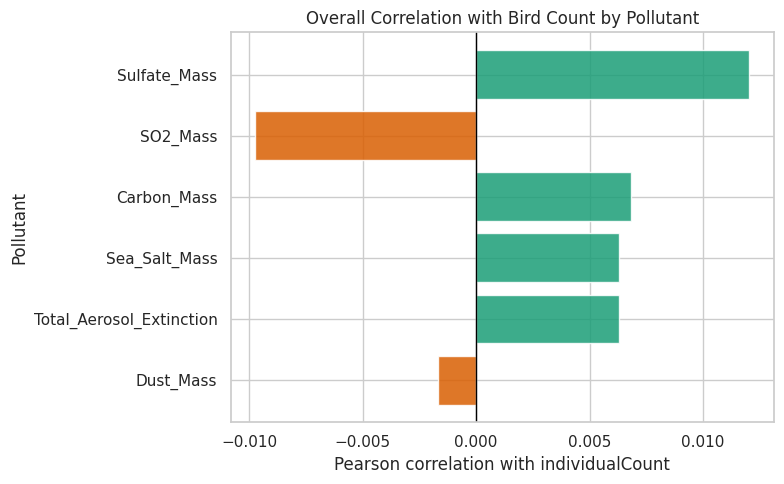

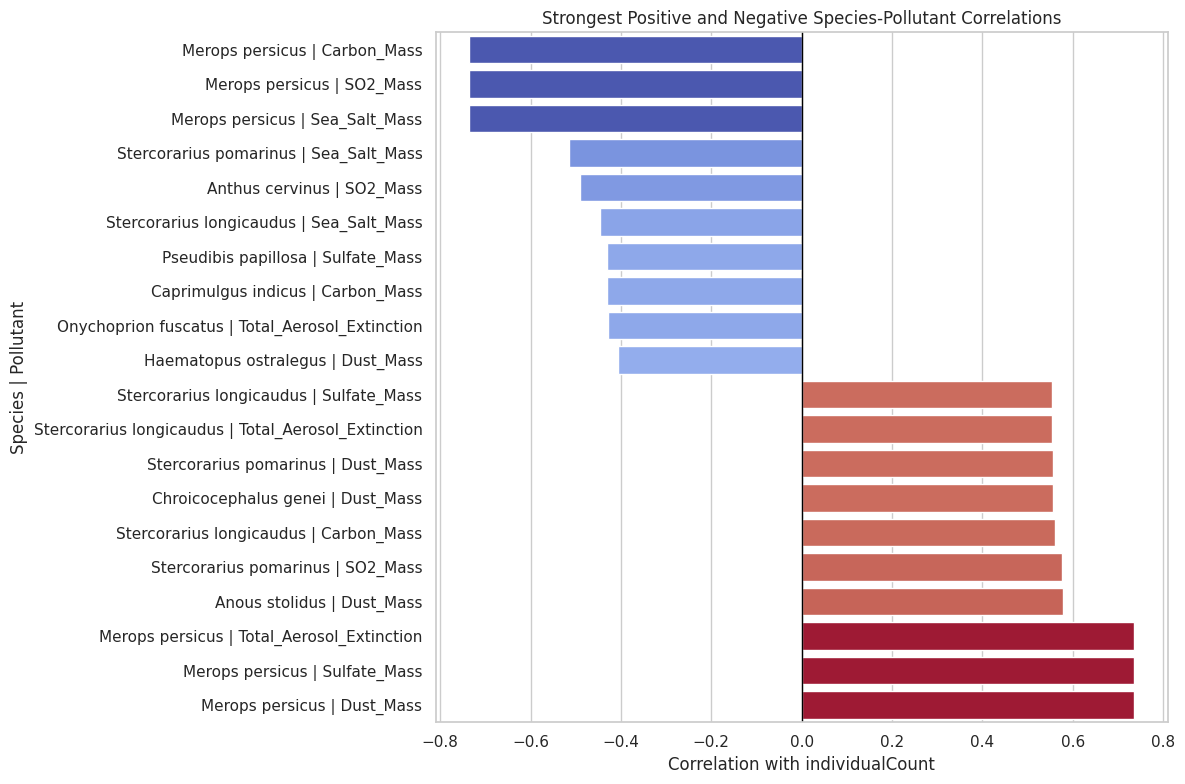

In [11]:
# Plot 1: Overall pollutant correlations (sorted by absolute value)
plot_overall = overall_corr.sort_values(key=lambda s: s.abs(), ascending=True)

plt.figure(figsize=(8, 5))
colors = ['#d95f02' if v < 0 else '#1b9e77' for v in plot_overall.values]
plt.barh(plot_overall.index, plot_overall.values, color=colors, alpha=0.85)
plt.axvline(0, color='black', linewidth=1)
plt.title('Overall Correlation with Bird Count by Pollutant')
plt.xlabel('Pearson correlation with individualCount')
plt.ylabel('Pollutant')
plt.tight_layout()
plt.show()

# Plot 2: Top strongest species-pollutant pairs (positive vs negative)
top_pos_plot = strongest_positive.head(10).copy()
top_neg_plot = strongest_negative.head(10).copy()

plot_pairs = pd.concat([top_pos_plot, top_neg_plot], ignore_index=True)
plot_pairs['pair_label'] = (
    plot_pairs['verbatimScientificName'].str.slice(0, 28) + ' | ' + plot_pairs['pollution_metric']
    )
plot_pairs = plot_pairs.sort_values('corr')

plt.figure(figsize=(12, 8))
sns.barplot(
    data=plot_pairs,
    y='pair_label',
    x='corr',
    hue='corr',
    dodge=False,
    palette='coolwarm'
    )
plt.axvline(0, color='black', linewidth=1)
plt.title('Strongest Positive and Negative Species-Pollutant Correlations')
plt.xlabel('Correlation with individualCount')
plt.ylabel('Species | Pollutant')
plt.legend([], [], frameon=False)
plt.tight_layout()
plt.show()

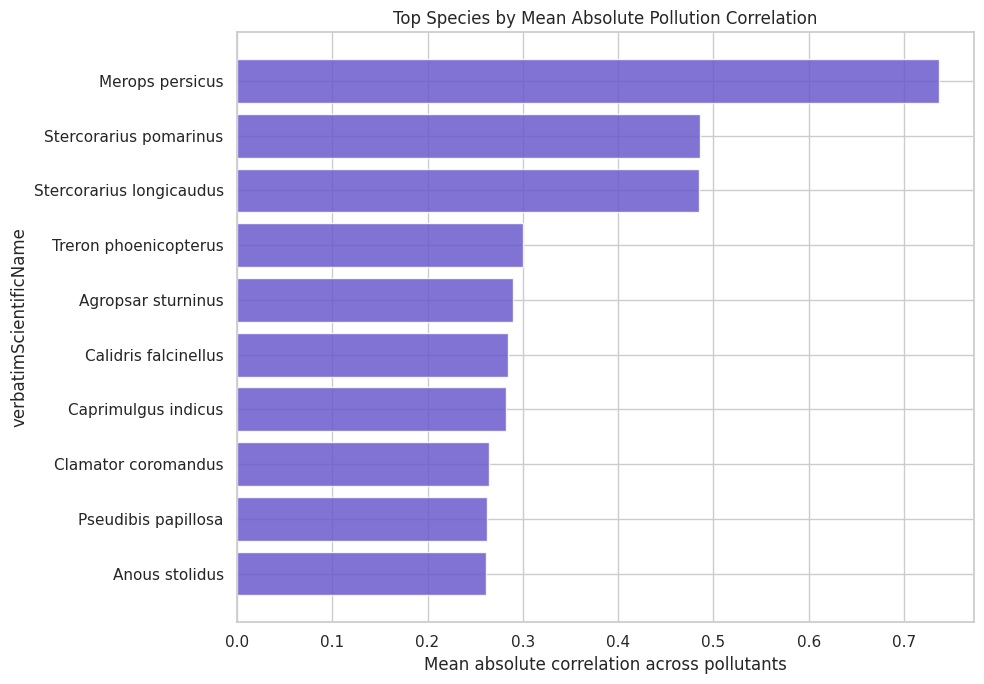

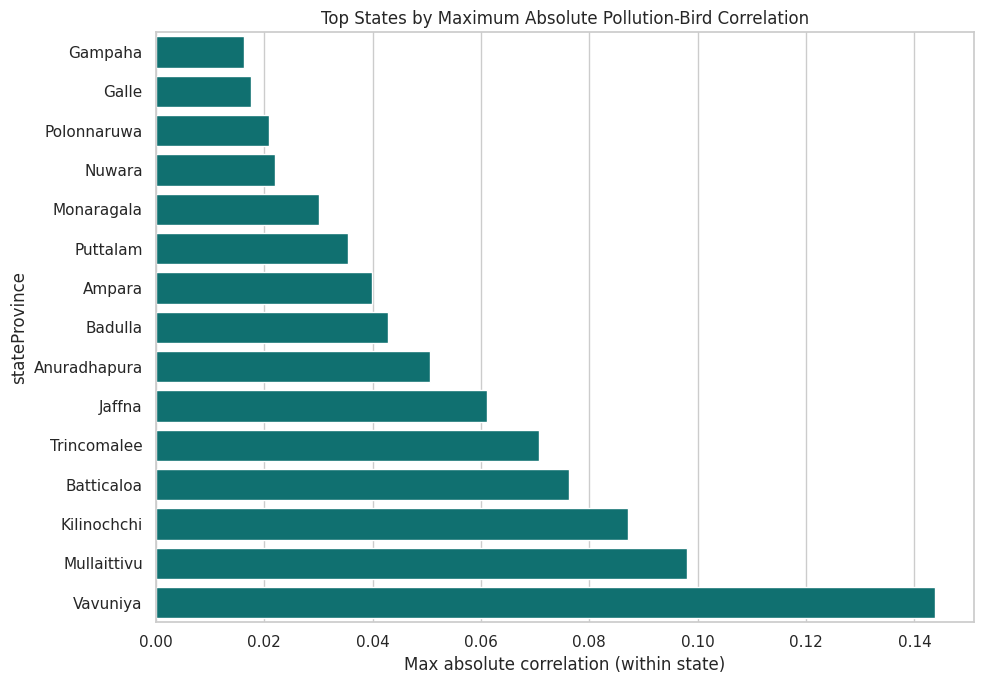

In [12]:
# Plot 3: Most pollution-responsive species (mean absolute correlation)
top_species_resp = species_response.head(15).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(top_species_resp.index, top_species_resp.values, color='slateblue', alpha=0.85)
plt.title('Top Species by Mean Absolute Pollution Correlation')
plt.xlabel('Mean absolute correlation across pollutants')
plt.ylabel('verbatimScientificName')
plt.tight_layout()
plt.show()

# Plot 4: States with strongest pollution-bird association
if 'state_report' in locals() and not state_report.empty:
    top_states = state_report.head(15).copy()
    top_states = top_states.sort_values('max_abs_corr', ascending=True)

    plt.figure(figsize=(10, 7))
    sns.barplot(data=top_states, y='stateProvince', x='max_abs_corr', color='teal')
    plt.title('Top States by Maximum Absolute Pollution-Bird Correlation')
    plt.xlabel('Max absolute correlation (within state)')
    plt.ylabel('stateProvince')
    plt.tight_layout()
    plt.show()
else:
    print('state_report is empty; run the state snapshot cell first.')

## Observation Bias and Spatial Autocorrelation Analysis (Air Pollution)
This section addresses spatial sampling bias in citizen-science observations by:
1. Quantifying how unevenly records are distributed across space.
2. Applying **spatial thinning** (one record per 5km grid cell).
3. Comparing air-pollution vs `individualCount` relationships before and after thinning.

Interpretation rule:
- If correlations change notably after thinning, part of the original signal was likely driven by clustered observer effort.
- If correlations remain similar, findings are more spatially robust.

Spatial sampling concentration diagnostics
- Total records: 1,552,048
- Unique 5km cells: 1,646
- Median records per cell: 81.0
- Max records in one cell: 115,157
- Share of records in top 10% most-sampled cells: 84.02%


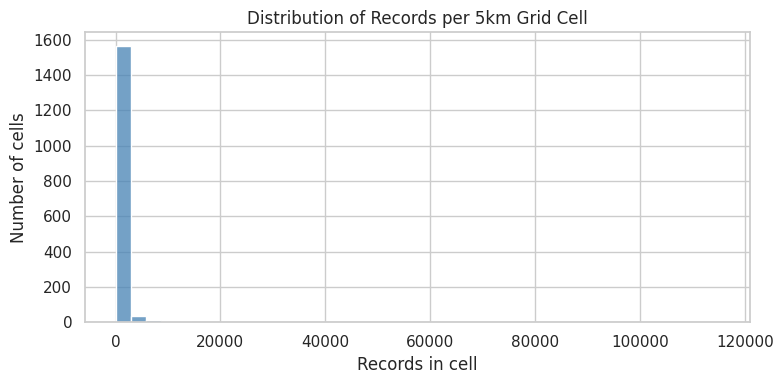

In [3]:
import numpy as np

# Optional p-values for Spearman (if scipy is available)
try:
    from scipy.stats import spearmanr
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

# --- 1) Build a 5km spatial grid and quantify clustering ---
grid_km = 5
spatial_df = analysis_df.dropna(subset=['decimalLatitude', 'decimalLongitude', 'individualCount'] + pollution_cols).copy()

# Approximate km coordinates (good for sub-national analyses)
lat_rad = np.radians(spatial_df['decimalLatitude'])
spatial_df['x_km'] = spatial_df['decimalLongitude'] * 111.320 * np.cos(lat_rad)
spatial_df['y_km'] = spatial_df['decimalLatitude'] * 110.574

spatial_df['grid_x'] = np.floor(spatial_df['x_km'] / grid_km).astype(int)
spatial_df['grid_y'] = np.floor(spatial_df['y_km'] / grid_km).astype(int)
spatial_df['grid_id'] = spatial_df['grid_x'].astype(str) + '_' + spatial_df['grid_y'].astype(str)

cell_counts = spatial_df['grid_id'].value_counts()
n_cells = cell_counts.size
n_records = len(spatial_df)

# Concentration diagnostics: how much data comes from top 10% most-sampled cells
k_top = max(1, int(np.ceil(0.10 * n_cells)))
share_top10 = cell_counts.head(k_top).sum() / n_records

print('Spatial sampling concentration diagnostics')
print(f'- Total records: {n_records:,}')
print(f'- Unique 5km cells: {n_cells:,}')
print(f'- Median records per cell: {cell_counts.median():.1f}')
print(f'- Max records in one cell: {cell_counts.max():,}')
print(f'- Share of records in top 10% most-sampled cells: {share_top10:.2%}')

# Visualize clustering intensity
plt.figure(figsize=(8, 4))
sns.histplot(cell_counts, bins=40, color='steelblue')
plt.title('Distribution of Records per 5km Grid Cell')
plt.xlabel('Records in cell')
plt.ylabel('Number of cells')
plt.tight_layout()
plt.show()

Spatial thinning summary
- Before thinning: 1,552,048 records
- After thinning:  1,646 records
- Retained fraction: 0.11%


,pollution_metric,rho_full,rho_thinned,abs_change,p_full,p_thinned,n_full,n_thinned
0,Dust_Mass,0.021899,0.075581,0.053682,NaN,NaN,1552048,1646
1,Sulfate_Mass,0.026575,-0.017345,0.043920,NaN,NaN,1552048,1646
2,Carbon_Mass,0.015401,-0.023204,0.038605,NaN,NaN,1552048,1646
3,Sea_Salt_Mass,0.064662,0.036537,0.028125,NaN,NaN,1552048,1646
4,SO2_Mass,-0.001256,-0.019741,0.018485,NaN,NaN,1552048,1646
5,Total_Aerosol_Extinction,0.038142,0.037363,0.000779,NaN,NaN,1552048,1646


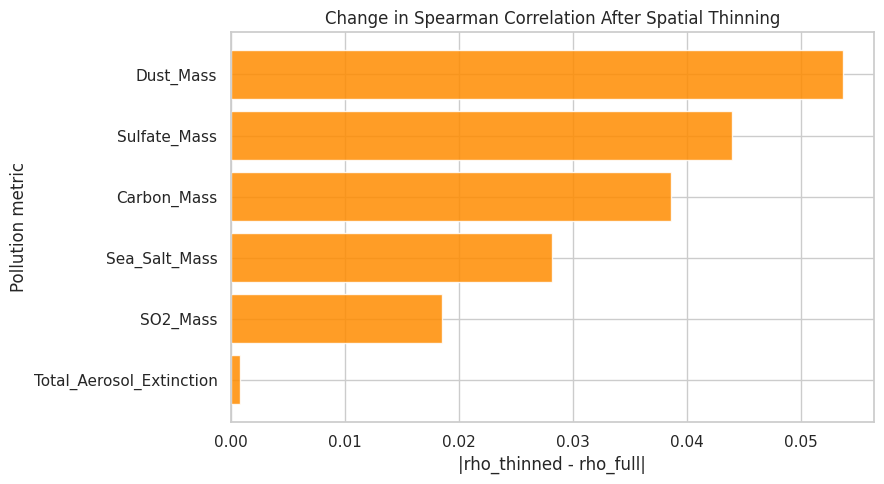

In [4]:
# --- 2) Spatial thinning: keep one random observation per 5km cell ---
rng = np.random.default_rng(42)

# Assign random number within each cell and keep one row per cell
thinned_df = (
    spatial_df
    .assign(_rand=rng.random(len(spatial_df)))
    .sort_values('_rand')
    .groupby('grid_id', as_index=False)
    .head(1)
    .drop(columns=['_rand'])
    .copy()
)

print('Spatial thinning summary')
print(f'- Before thinning: {len(spatial_df):,} records')
print(f'- After thinning:  {len(thinned_df):,} records')
print(f'- Retained fraction: {len(thinned_df)/len(spatial_df):.2%}')

# --- 3) Compare pollutant relationships before vs after thinning ---
rows = []
for metric in pollution_cols:
    full_sub = spatial_df[[metric, 'individualCount']].dropna()
    thin_sub = thinned_df[[metric, 'individualCount']].dropna()

    rho_full = full_sub.corr(method='spearman').loc[metric, 'individualCount']
    rho_thin = thin_sub.corr(method='spearman').loc[metric, 'individualCount']

    if SCIPY_AVAILABLE:
        _, p_full = spearmanr(full_sub[metric], full_sub['individualCount'])
        _, p_thin = spearmanr(thin_sub[metric], thin_sub['individualCount'])
    else:
        p_full, p_thin = np.nan, np.nan

    rows.append({
        'pollution_metric': metric,
        'rho_full': rho_full,
        'rho_thinned': rho_thin,
        'abs_change': abs(rho_thin - rho_full),
        'p_full': p_full,
        'p_thinned': p_thin,
        'n_full': len(full_sub),
        'n_thinned': len(thin_sub),
    })

bias_impact_df = pd.DataFrame(rows).sort_values('abs_change', ascending=False).reset_index(drop=True)
display(bias_impact_df)

# Visualization of change magnitude
plot_df = bias_impact_df.sort_values('abs_change', ascending=True)
plt.figure(figsize=(9, 5))
plt.barh(plot_df['pollution_metric'], plot_df['abs_change'], color='darkorange', alpha=0.85)
plt.title('Change in Spearman Correlation After Spatial Thinning')
plt.xlabel('|rho_thinned - rho_full|')
plt.ylabel('Pollution metric')
plt.tight_layout()
plt.show()

In [5]:
# Compact interpretation text for report writing
if not bias_impact_df.empty:
    mean_abs_change = bias_impact_df['abs_change'].mean()
    max_row = bias_impact_df.iloc[0]

    print('Interpretation summary')
    print(f"- Average absolute correlation change across pollutants after thinning: {mean_abs_change:.4f}")
    print(
        f"- Largest change: {max_row['pollution_metric']} "
        f"(|Δrho| = {max_row['abs_change']:.4f}, "
        f"rho_full = {max_row['rho_full']:.4f}, rho_thinned = {max_row['rho_thinned']:.4f})"
    )

    if SCIPY_AVAILABLE:
        significant_full = (bias_impact_df['p_full'] < 0.05).sum()
        significant_thin = (bias_impact_df['p_thinned'] < 0.05).sum()
        print(f"- Significant pollutant associations (p < 0.05): full={significant_full}, thinned={significant_thin}")

    print('\nSuggested limitation statement:')
    print(
        'Citizen-science observations are spatially clustered around accessible locations, '
        'which can inflate nominal statistical significance in correlation-based analyses. '
        'A 5km spatial thinning sensitivity check was applied to reduce over-representation '
        'from heavily sampled cells. Pollution-bird relationships were compared before and '
        'after thinning to assess robustness to observation bias and spatial autocorrelation.'
    )

Interpretation summary
- Average absolute correlation change across pollutants after thinning: 0.0306
- Largest change: Dust_Mass (|Δrho| = 0.0537, rho_full = 0.0219, rho_thinned = 0.0756)

Suggested limitation statement:
Citizen-science observations are spatially clustered around accessible locations, which can inflate nominal statistical significance in correlation-based analyses. A 5km spatial thinning sensitivity check was applied to reduce over-representation from heavily sampled cells. Pollution-bird relationships were compared before and after thinning to assess robustness to observation bias and spatial autocorrelation.


Top 15 strongest positive per-species correlations


,dataset,verbatimScientificName,pollution_metric,method,corr,abs_corr,n_records
3768,thinned,Egretta garzetta,Dust_Mass,pearson,0.590860,0.590860,22
3769,thinned,Psittacula krameri,Dust_Mass,pearson,0.556122,0.556122,22
0,full,Calidris falcinellus,Total_Aerosol_Extinction,pearson,0.537269,0.537269,145
3,full,Glareola maldivarum,Sea_Salt_Mass,spearman,0.509748,0.509748,245
3770,thinned,Dicaeum erythrorhynchos,Dust_Mass,spearman,0.506689,0.506689,16
3771,thinned,Spilornis cheela,SO2_Mass,spearman,0.506470,0.506470,18
3772,thinned,Aegithina tiphia,Total_Aerosol_Extinction,pearson,0.504041,0.504041,15
3773,thinned,Spilopelia chinensis,Sulfate_Mass,pearson,0.497614,0.497614,40
4,full,Clamator coromandus,Total_Aerosol_Extinction,spearman,0.472310,0.472310,160
3775,thinned,Pycnonotus luteolus,Sulfate_Mass,spearman,0.448586,0.448586,19


Top 15 strongest negative per-species correlations


,dataset,verbatimScientificName,pollution_metric,method,corr,abs_corr,n_records
1,full,Stercorarius parasiticus,Sulfate_Mass,spearman,-0.512087,0.512087,104
2,full,Stercorarius parasiticus,Carbon_Mass,spearman,-0.512087,0.512087,104
3774,thinned,Spilornis cheela,Sea_Salt_Mass,spearman,-0.492849,0.492849,18
5,full,Glareola maldivarum,Carbon_Mass,spearman,-0.460704,0.460704,245
6,full,Calandrella dukhunensis,Dust_Mass,spearman,-0.448625,0.448625,135
3776,thinned,Cypsiurus balasiensis,SO2_Mass,spearman,-0.445450,0.445450,25
8,full,Haematopus ostralegus,Dust_Mass,spearman,-0.443879,0.443879,94
9,full,Glareola maldivarum,Sulfate_Mass,spearman,-0.442283,0.442283,245
3778,thinned,Halcyon smyrnensis,Carbon_Mass,spearman,-0.440523,0.440523,29
3780,thinned,Copsychus saularis,Carbon_Mass,pearson,-0.425665,0.425665,24



Most robust species-pollutant correlations (same sign in full and thinned)


,verbatimScientificName,pollution_metric,method,corr_full,n_full,corr_thinned,n_thinned,same_sign,abs_change,strength_score
0,Cypsiurus balasiensis,SO2_Mass,spearman,-0.263128,14339,-0.445450,25,True,0.182322,0.354289
317,Egretta garzetta,Dust_Mass,pearson,0.014223,15766,0.590860,22,True,0.576637,0.302541
31,Dicaeum erythrorhynchos,Dust_Mass,spearman,0.091117,22965,0.506689,16,True,0.415572,0.298903
4,Microcarbo niger,SO2_Mass,spearman,-0.153604,18114,-0.406214,17,True,0.252611,0.279909
100,Aegithina tiphia,Total_Aerosol_Extinction,pearson,0.050348,8958,0.504041,15,True,0.453693,0.277194
19,Psittacula krameri,SO2_Mass,spearman,0.109311,32501,0.431975,22,True,0.322664,0.270643
245,Spilornis cheela,Sea_Salt_Mass,spearman,-0.025072,7302,-0.492849,18,True,0.467777,0.258960
355,Spilopelia chinensis,Sulfate_Mass,pearson,0.009126,41311,0.497614,40,True,0.488488,0.253370
8,Spilopelia chinensis,SO2_Mass,spearman,-0.135124,41311,-0.358887,40,True,0.223763,0.247006
18,Spilopelia chinensis,SO2_Mass,pearson,-0.109878,41311,-0.359536,40,True,0.249658,0.234707


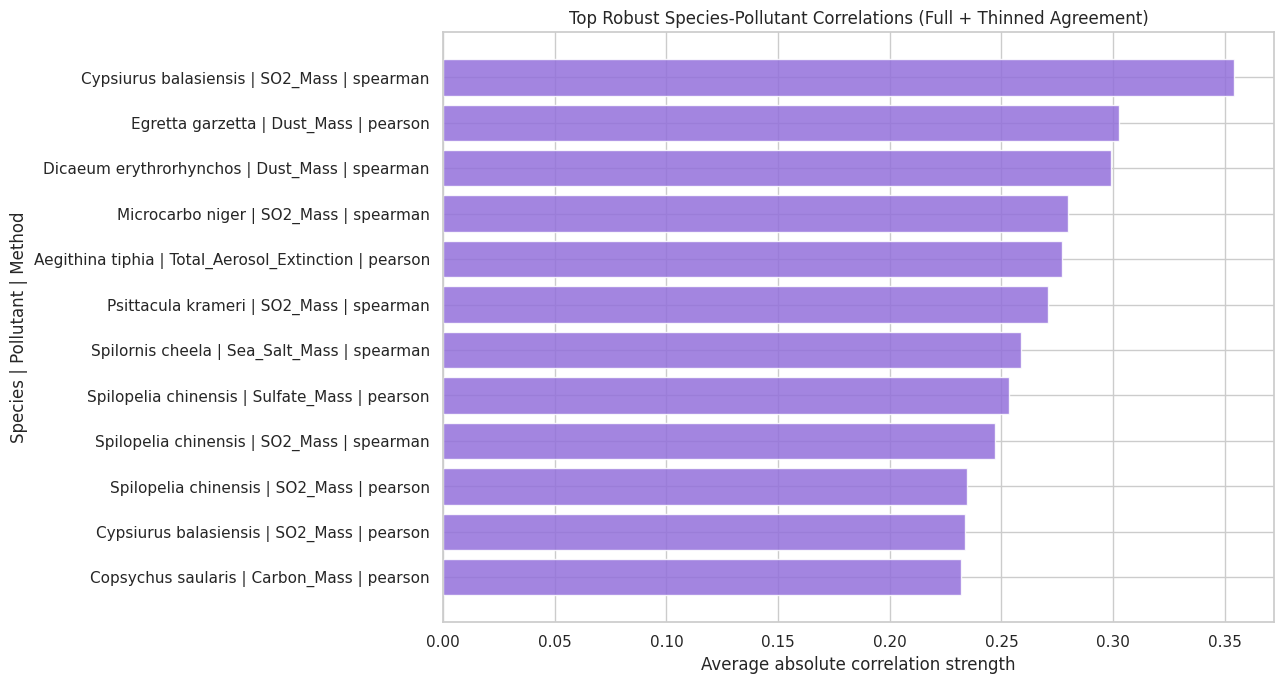

In [8]:
# Focused summaries: strongest positive/negative and robust (full+thinned) links
if species_corr_all.empty:
    print('No per-species correlations met minimum record thresholds.')
else:
    strongest_positive_species = species_corr_all.sort_values('corr', ascending=False).head(15)
    strongest_negative_species = species_corr_all.sort_values('corr', ascending=True).head(15)

    print('Top 15 strongest positive per-species correlations')
    display(strongest_positive_species)

    print('Top 15 strongest negative per-species correlations')
    display(strongest_negative_species)

    overlap_keys = ['verbatimScientificName', 'pollution_metric', 'method']
    full_keyed = species_corr_full_all[overlap_keys + ['corr', 'n_records']].rename(
        columns={'corr': 'corr_full', 'n_records': 'n_full'}
    )
    thin_keyed = species_corr_thinned_all[overlap_keys + ['corr', 'n_records']].rename(
        columns={'corr': 'corr_thinned', 'n_records': 'n_thinned'}
    )

    robust_links = full_keyed.merge(thin_keyed, on=overlap_keys, how='inner')
    if robust_links.empty:
        print('No overlap between full and thinned species-method-metric combinations at current thresholds.')
    else:
        robust_links['same_sign'] = np.sign(robust_links['corr_full']) == np.sign(robust_links['corr_thinned'])
        robust_links['abs_change'] = (robust_links['corr_thinned'] - robust_links['corr_full']).abs()
        robust_links['strength_score'] = (robust_links['corr_full'].abs() + robust_links['corr_thinned'].abs()) / 2

        robust_ranked = robust_links[robust_links['same_sign']].sort_values(
            ['strength_score', 'abs_change'], ascending=[False, True]
        )

        print('\nMost robust species-pollutant correlations (same sign in full and thinned)')
        display(robust_ranked.head(20))

        top_plot = robust_ranked.head(12).copy()
        if not top_plot.empty:
            top_plot['label'] = (
                top_plot['verbatimScientificName'].str.slice(0, 24)
                + ' | '
                + top_plot['pollution_metric']
                + ' | '
                + top_plot['method']
            )
            top_plot = top_plot.sort_values('strength_score', ascending=True)

            plt.figure(figsize=(13, 7))
            plt.barh(top_plot['label'], top_plot['strength_score'], color='mediumpurple', alpha=0.85)
            plt.title('Top Robust Species-Pollutant Correlations (Full + Thinned Agreement)')
            plt.xlabel('Average absolute correlation strength')
            plt.ylabel('Species | Pollutant | Method')
            plt.tight_layout()
            plt.show()

In [7]:
# Per-species correlations across all pollutants and methods
min_species_records_full = 80
min_species_records_thinned = 15

# In this environment scipy may be unavailable.
# We always compute Pearson.
# We compute Spearman using rank transformation (scipy-free fallback).
# We compute Kendall only when scipy is available.
corr_methods = ['pearson', 'spearman'] + (['kendall'] if SCIPY_AVAILABLE else [])

def compute_corr(x, y, method):
    if method == 'pearson':
        return x.corr(y, method='pearson')
    if method == 'spearman':
        return x.rank(method='average').corr(y.rank(method='average'), method='pearson')
    if method == 'kendall':
        return x.corr(y, method='kendall')
    return np.nan

def build_species_correlation_table(source_df, dataset_label, min_records):
    records = []
    species_counts = source_df['verbatimScientificName'].value_counts()
    valid_species = species_counts[species_counts >= min_records].index

    for species in valid_species:
        species_df = source_df[source_df['verbatimScientificName'] == species]

        for metric in pollution_cols:
            pair_df = species_df[[metric, 'individualCount']].dropna()
            if len(pair_df) < min_records:
                continue

            x = pair_df[metric]
            y = pair_df['individualCount']

            for method in corr_methods:
                corr_val = compute_corr(x, y, method)
                if pd.isna(corr_val):
                    continue

                records.append({
                    'dataset': dataset_label,
                    'verbatimScientificName': species,
                    'pollution_metric': metric,
                    'method': method,
                    'corr': corr_val,
                    'abs_corr': abs(corr_val),
                    'n_records': len(pair_df),
                })

    result = pd.DataFrame(records)
    if not result.empty:
        result = result.sort_values('abs_corr', ascending=False).reset_index(drop=True)
    return result

species_corr_full_all = build_species_correlation_table(spatial_df, 'full', min_species_records_full)
species_corr_thinned_all = build_species_correlation_table(thinned_df, 'thinned', min_species_records_thinned)
species_corr_all = pd.concat([species_corr_full_all, species_corr_thinned_all], ignore_index=True)

print('Per-species correlation mining summary')
print(f'- Methods used: {corr_methods}')
print(f'- Full dataset correlations: {len(species_corr_full_all):,}')
print(f'- Thinned dataset correlations: {len(species_corr_thinned_all):,}')
print(f'- Total correlations mined: {len(species_corr_all):,}')

print('\nTop 20 strongest absolute correlations (all methods, all pollutants)')
display(species_corr_all.head(20))

Per-species correlation mining summary
- Methods used: ['pearson', 'spearman']
- Full dataset correlations: 3,768
- Thinned dataset correlations: 420
- Total correlations mined: 4,188

Top 20 strongest absolute correlations (all methods, all pollutants)


,dataset,verbatimScientificName,pollution_metric,method,corr,abs_corr,n_records
0,full,Calidris falcinellus,Total_Aerosol_Extinction,pearson,0.537269,0.537269,145
1,full,Stercorarius parasiticus,Sulfate_Mass,spearman,-0.512087,0.512087,104
2,full,Stercorarius parasiticus,Carbon_Mass,spearman,-0.512087,0.512087,104
3,full,Glareola maldivarum,Sea_Salt_Mass,spearman,0.509748,0.509748,245
4,full,Clamator coromandus,Total_Aerosol_Extinction,spearman,0.472310,0.472310,160
5,full,Glareola maldivarum,Carbon_Mass,spearman,-0.460704,0.460704,245
6,full,Calandrella dukhunensis,Dust_Mass,spearman,-0.448625,0.448625,135
7,full,Clamator coromandus,Total_Aerosol_Extinction,pearson,0.446442,0.446442,160
8,full,Haematopus ostralegus,Dust_Mass,spearman,-0.443879,0.443879,94
9,full,Glareola maldivarum,Sulfate_Mass,spearman,-0.442283,0.442283,245


## Per-Species Correlation Mining (After Spatial Unit-Area Thinning)
This section searches for species-specific bird–pollution relationships using multiple correlation methods:
- Pearson (linear)
- Spearman (monotonic rank)
- Kendall (rank concordance)

It reports results for both the full spatial dataset (`spatial_df`) and the spatially thinned dataset (`thinned_df`).
To avoid unstable estimates, each species must meet a minimum record threshold.